# EDA Advanced — MBO Realized Volatility Feature Table

Follows the analytical pattern from *Python for Data Analysis* (McKinney, Ch. 5, 9, 10, 11):
correlation → grouped aggregations → rolling/resampling → financial time series patterns.

Answers the questions a modeling notebook needs:
- Which features correlate with the RV targets?
- Is `rv_past_60` a useful predictor of `rv_next_60`?
- Do symbols share RV dynamics, or do we need per-symbol models?
- What intraday patterns exist that could be features?
- Which sessions should be excluded before splitting train/test?

Run **EDA_basic.ipynb** first, then use this notebook to inform modeling decisions.

## 0. Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = "/content/drive/MyDrive/CIS545_Group_Project/processed_data/mbo_features_table"
    IN_COLAB = True
except ImportError:
    DATA_PATH = os.path.expanduser("~/Downloads/mbo_features_table")
    IN_COLAB = False

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Path exists : {os.path.exists(DATA_PATH)}")

Environment : Local
Path exists : True


## 1. Load Data

In [2]:
SYMBOLS = ["ZT.c.0", "ZF.c.0", "ZN.c.0", "ZB.c.0", "TN.c.0", "UB.c.0",
           "CL.c.0", "BZ.c.0", "6E.c.0"]

df = pd.read_parquet(DATA_PATH, filters=[("symbol", "in", SYMBOLS)])
df["second_bucket"] = pd.to_datetime(df["second_bucket"])
df["session_date"]  = pd.to_datetime(df["session_date"]).dt.date

print(f"Rows    : {len(df):,}")
print(f"Symbols : {sorted(df['symbol'].unique())}")
print(f"Date range: {df['session_date'].min()} → {df['session_date'].max()}")

Rows    : 28,681,716
Symbols : ['6E.c.0', 'BZ.c.0', 'CL.c.0', 'TN.c.0', 'UB.c.0', 'ZB.c.0', 'ZF.c.0', 'ZN.c.0', 'ZT.c.0']
Date range: 2025-11-17 → 2026-01-16


## 2. Holiday / Anomalous Session Identification

holiday-period sessions as having abnormal activity.

In [3]:
FULL_SESSION_SECS = 82800 - 59 - 300  # 82,441 after trimming

sess_stats = (
    df.groupby(["symbol", "session_date"])
    .agg(
        n_seconds=("second_bucket", "count"),
        n_trades=("n_trade", "sum"),
        median_events=("n_events", "median"),
    )
    .reset_index()
)

# flag sessions with fewer than 80% of expected seconds
sess_stats["is_short"] = sess_stats["n_seconds"] < FULL_SESSION_SECS * 0.8

short_sessions = sess_stats[sess_stats["is_short"]].sort_values("n_seconds")
print(f"Anomalous sessions detected: {short_sessions['session_date'].nunique()} unique dates")
print(short_sessions[["session_date", "symbol", "n_seconds", "n_trades"]].to_string())

# recommended dates to exclude
EXCLUDE_DATES = sorted(short_sessions["session_date"].unique().tolist())
# also exclude the known final session
import datetime
final_session = datetime.date(2026, 1, 16)
if final_session not in EXCLUDE_DATES:
    EXCLUDE_DATES.append(final_session)
print(f"\nDates to exclude: {EXCLUDE_DATES}")

Anomalous sessions detected: 20 unique dates
    session_date  symbol  n_seconds  n_trades
42    2026-01-16  6E.c.0          0         0
372   2025-12-26  ZT.c.0          0         0
147   2025-12-11  TN.c.0          0         0
371   2025-12-24  ZT.c.0          0         0
283   2025-12-22  ZF.c.0          0         0
284   2025-12-23  ZF.c.0          0         0
194   2025-12-17  UB.c.0          0         0
289   2025-12-31  ZF.c.0          0         0
286   2025-12-26  ZF.c.0       6901         0
152   2025-12-18  TN.c.0       7876         1
281   2025-12-18  ZF.c.0      14090         4
192   2025-12-15  UB.c.0      19052       173
238   2025-12-18  ZB.c.0      19904         2
373   2025-12-29  ZT.c.0      21884         0
232   2025-12-10  ZB.c.0      22631        12
287   2025-12-29  ZF.c.0      23931         1
321   2025-12-15  ZN.c.0      24176         4
288   2025-12-30  ZF.c.0      25459        11
374   2025-12-30  ZT.c.0      26609         0
360   2025-12-09  ZT.c.0      26864

In [4]:
# clean dataset for modeling analysis
df_clean = df[~df["session_date"].isin(EXCLUDE_DATES)].copy()
rv_clean  = df_clean[df_clean["rv_past_60"] > 0].copy()

print(f"Rows after excluding anomalous sessions : {len(df_clean):,}")
print(f"Rows with non-zero rv_past_60           : {len(rv_clean):,}")

Rows after excluding anomalous sessions : 16,951,196
Rows with non-zero rv_past_60           : 8,687,280


## 3. RV Distributions

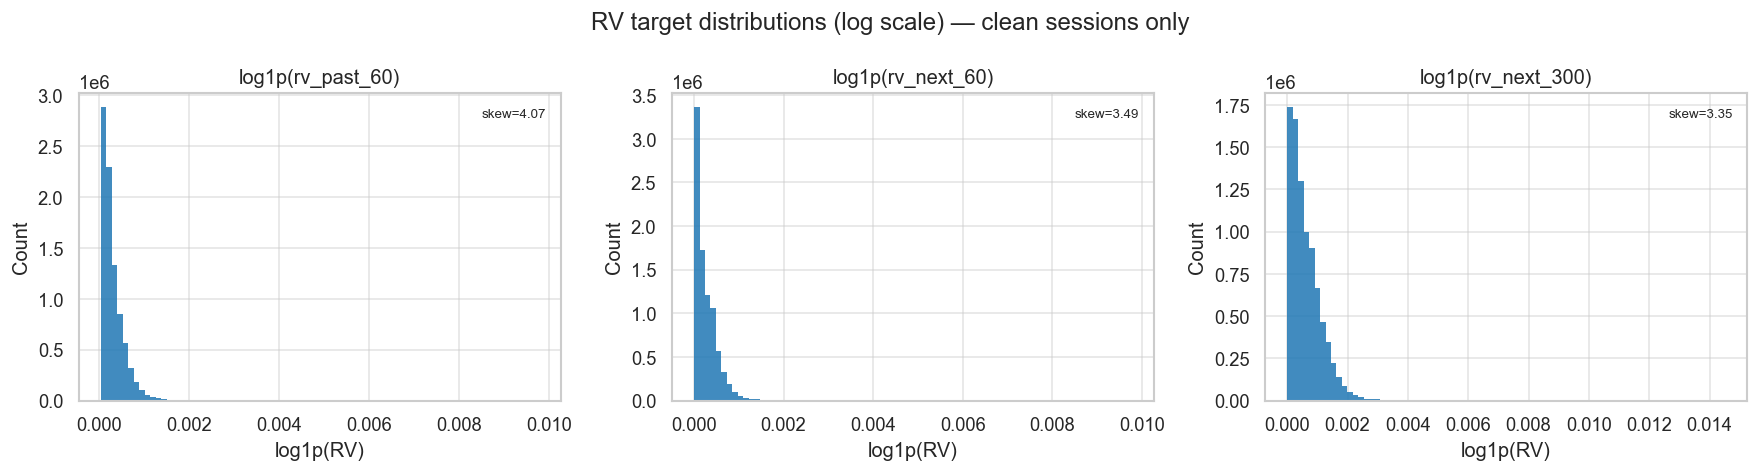

Modeling note: RV is right-skewed. Consider log1p transform or Huber loss.


In [5]:
rv_cols  = [c for c in ["rv_past_60", "rv_next_60", "rv_next_300"] if c in df.columns]

fig, axes = plt.subplots(1, len(rv_cols), figsize=(5 * len(rv_cols), 4))
if len(rv_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, rv_cols):
    vals = rv_clean[col].dropna()
    ax.hist(np.log1p(vals), bins=80, edgecolor="none", alpha=0.85)
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p(RV)")
    ax.set_ylabel("Count")
    ax.text(0.97, 0.95, f"skew={vals.skew():.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8)
plt.suptitle("RV target distributions (log scale) — clean sessions only")
plt.tight_layout()
plt.show()

print("Modeling note: RV is right-skewed. Consider log1p transform or Huber loss.")

Median RV by symbol:


,rv_past_60,rv_next_60,rv_next_300
symbol,,,
CL.c.0,0.000455,0.000449,0.001071
BZ.c.0,0.000447,0.000348,0.000966
ZB.c.0,0.000379,0.000271,0.000713
UB.c.0,0.000365,0.000264,0.000635
ZN.c.0,0.000241,0.000239,0.000536
TN.c.0,0.000191,0.000136,0.000359
ZF.c.0,0.000101,0.000101,0.000236
6E.c.0,0.000087,0.000086,0.000197
ZT.c.0,0.000053,0.000037,0.000092


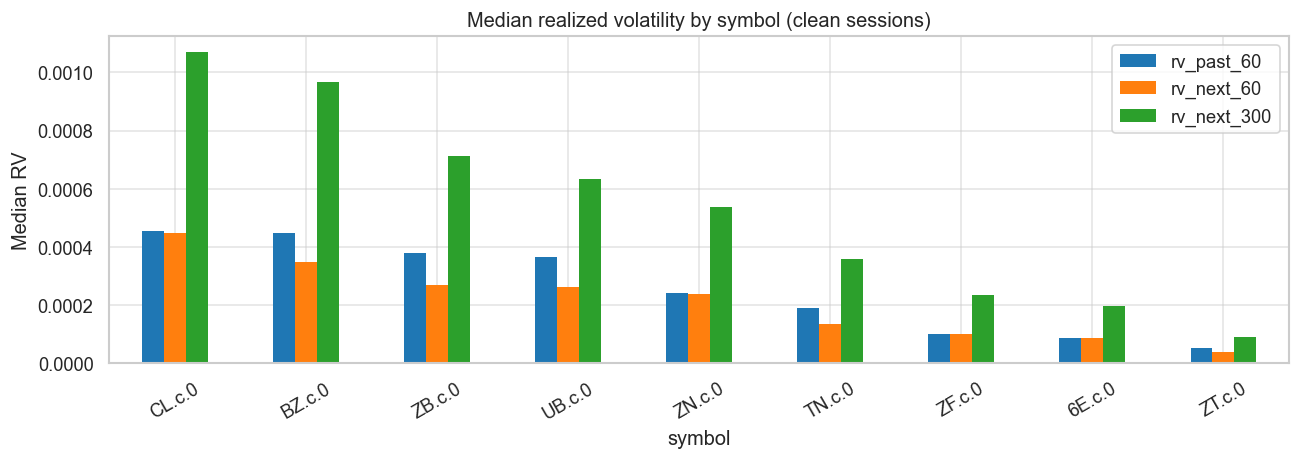


Modeling note: RV levels differ significantly across symbols.
Consider per-symbol models or normalizing RV within symbol.


In [6]:
# median RV by symbol — informs whether a pooled or per-symbol model is needed
rv_by_sym = rv_clean.groupby("symbol")[rv_cols].median().sort_values("rv_past_60", ascending=False)
print("Median RV by symbol:")
display(rv_by_sym)

rv_by_sym.plot(kind="bar", figsize=(11, 4), edgecolor="none")
plt.title("Median realized volatility by symbol (clean sessions)")
plt.ylabel("Median RV")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nModeling note: RV levels differ significantly across symbols.")
print("Consider per-symbol models or normalizing RV within symbol.")

## 4. Predictive Signal: rv_past_60 → rv_next_60

Is past RV a useful predictor of future RV? This is the baseline any model must beat.

In [7]:
# corr() per symbol
corr_past_next = (
    rv_clean.groupby("symbol")[["rv_past_60", "rv_next_60"]]
    .corr()
    .unstack()["rv_past_60"]["rv_next_60"]
    .rename("pearson_r")
    .sort_values(ascending=False)
    .round(4)
)
print("Pearson corr(rv_past_60, rv_next_60) per symbol:")
display(corr_past_next)

# corrwith() — correlation of one Series against many columns
rv_features = rv_clean[["rv_past_60", "rv_next_60", "rv_next_300"]].dropna()
print("\ncorrwith(rv_next_60) across RV columns:")
print(rv_features.corrwith(rv_features["rv_next_60"]).round(4))

print("\nModeling note: rv_past_60 is a strong baseline predictor.")
print("Any model should outperform simply predicting rv_next_60 = rv_past_60.")

Pearson corr(rv_past_60, rv_next_60) per symbol:


symbol
ZN.c.0    0.6224
CL.c.0    0.6217
ZF.c.0    0.5255
BZ.c.0    0.4062
TN.c.0    0.3921
ZT.c.0    0.3687
ZB.c.0    0.3587
UB.c.0    0.3357
6E.c.0    0.2254
Name: pearson_r, dtype: float64


corrwith(rv_next_60) across RV columns:
rv_past_60     0.653
rv_next_60     1.000
rv_next_300    0.817
dtype: float64

Modeling note: rv_past_60 is a strong baseline predictor.
Any model should outperform simply predicting rv_next_60 = rv_past_60.


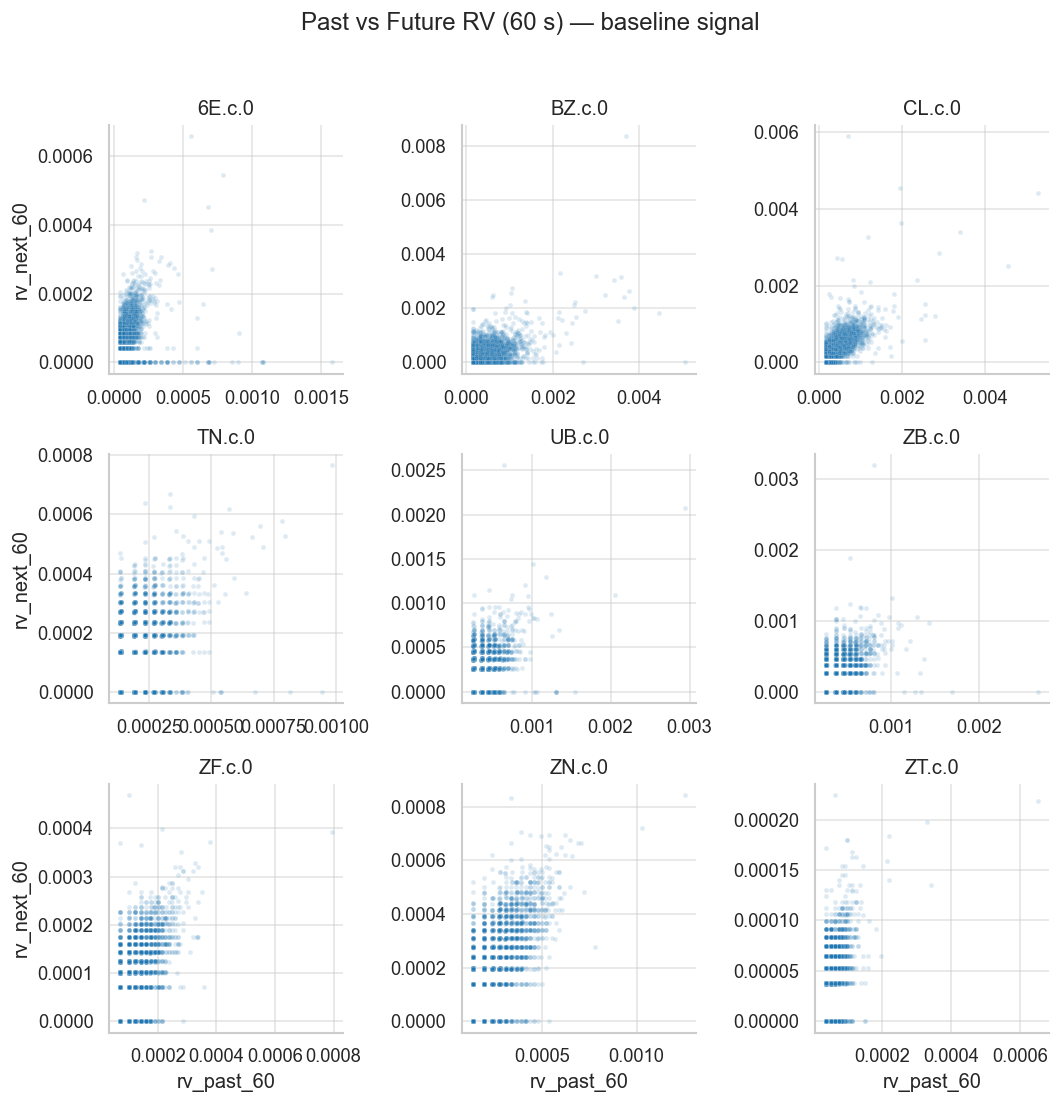

In [8]:
# scatter plot: past vs future RV (sample)
sample = rv_clean.groupby("symbol", group_keys=False).apply(
    lambda g: g.sample(min(3000, len(g)), random_state=42)
)
g = sns.FacetGrid(sample, col="symbol", col_wrap=3, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="rv_past_60", y="rv_next_60", alpha=0.15, s=8)
g.set_titles("{col_name}")
g.set_axis_labels("rv_past_60", "rv_next_60")
g.figure.suptitle("Past vs Future RV (60 s) — baseline signal", y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature → Target Correlation

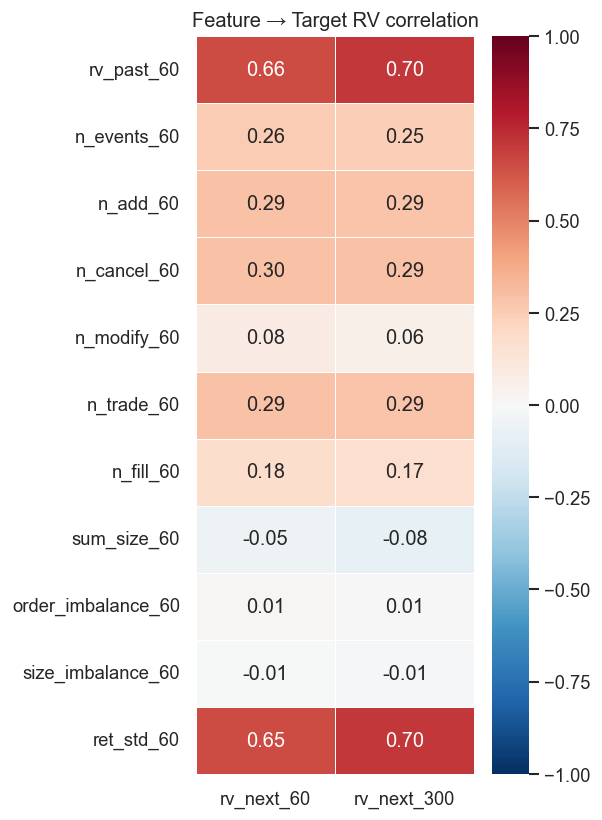

Feature ranking by |corr| with rv_next_60 (corrwith):


rv_past_60            0.6553
ret_std_60            0.6550
n_cancel_60           0.2963
n_add_60              0.2934
n_trade_60            0.2911
n_events_60           0.2561
n_fill_60             0.1789
n_modify_60           0.0788
sum_size_60           0.0502
order_imbalance_60    0.0079
size_imbalance_60     0.0066
dtype: float64

In [9]:
feature_cols = [
    "rv_past_60",
    "n_events_60", "n_add_60", "n_cancel_60", "n_modify_60",
    "n_trade_60", "n_fill_60", "sum_size_60",
    "order_imbalance_60", "size_imbalance_60", "ret_std_60",
]
targets      = [c for c in ["rv_next_60", "rv_next_300"] if c in df.columns]
feature_cols = [c for c in feature_cols if c in df.columns]

# full corr() matrix sliced
corr_block = df_clean[feature_cols + targets].corr().loc[feature_cols, targets]

fig, ax = plt.subplots(figsize=(5, 7))
sns.heatmap(
    corr_block, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax
)
ax.set_title("Feature → Target RV correlation")
plt.tight_layout()
plt.show()

# corrwith() — compact ranked feature list
print("Feature ranking by |corr| with rv_next_60 (corrwith):")
df_clean[feature_cols + ["rv_next_60"]].corrwith(df_clean["rv_next_60"]) \
    .drop("rv_next_60") \
    .abs() \
    .sort_values(ascending=False) \
    .round(4)

## 6. Intraday RV Pattern

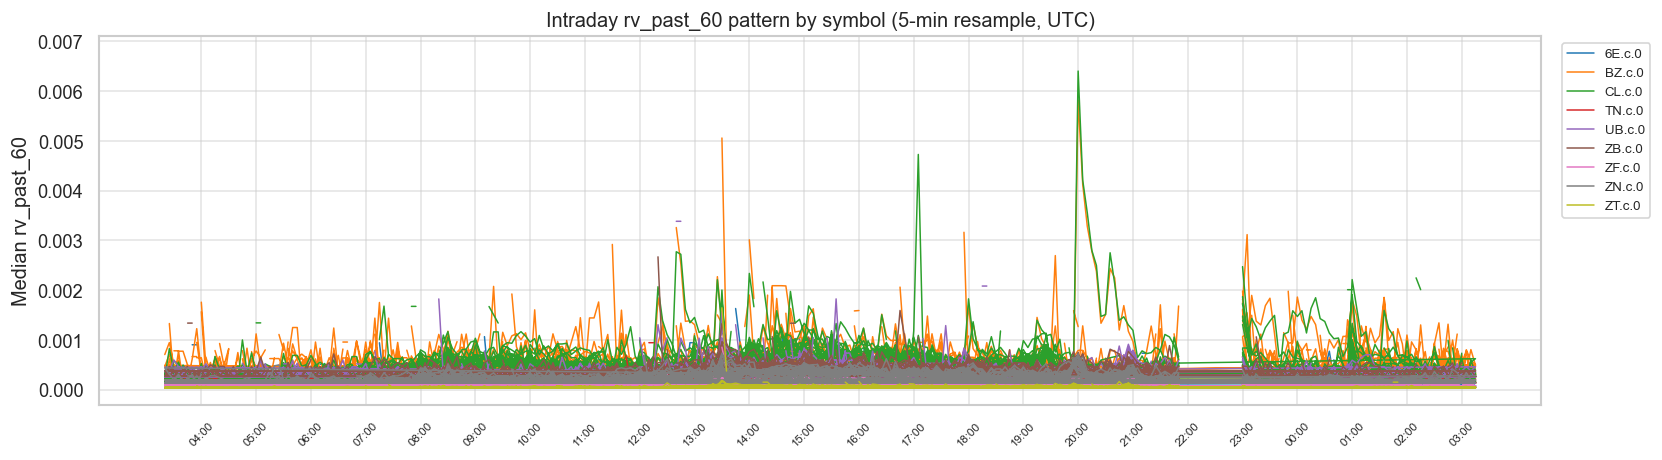

Modeling note: strong time-of-day effects — consider hour-of-day or minutes-since-open as a feature.


In [10]:
# resample to 5-min median RV per symbol
rv_tod = (
    df_clean[df_clean["rv_past_60"] > 0]
    .set_index("second_bucket")
    .groupby("symbol")["rv_past_60"]
    .resample("5min")
    .median()
    .reset_index()
)
rv_tod["time_of_day"] = rv_tod["second_bucket"].dt.strftime("%H:%M")

fig, ax = plt.subplots(figsize=(14, 4))
for sym, grp in rv_tod.groupby("symbol"):
    grp_sorted = grp.sort_values("second_bucket")
    ax.plot(grp_sorted["time_of_day"], grp_sorted["rv_past_60"], label=sym, linewidth=0.9)

ticks = sorted(rv_tod["time_of_day"].unique())
ax.set_xticks(ticks[::12])
ax.set_xticklabels(ticks[::12], rotation=45, fontsize=7)
ax.set_title("Intraday rv_past_60 pattern by symbol (5-min resample, UTC)")
ax.set_ylabel("Median rv_past_60")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("Modeling note: strong time-of-day effects — consider hour-of-day or minutes-since-open as a feature.")

## 7. Order Imbalance Distribution

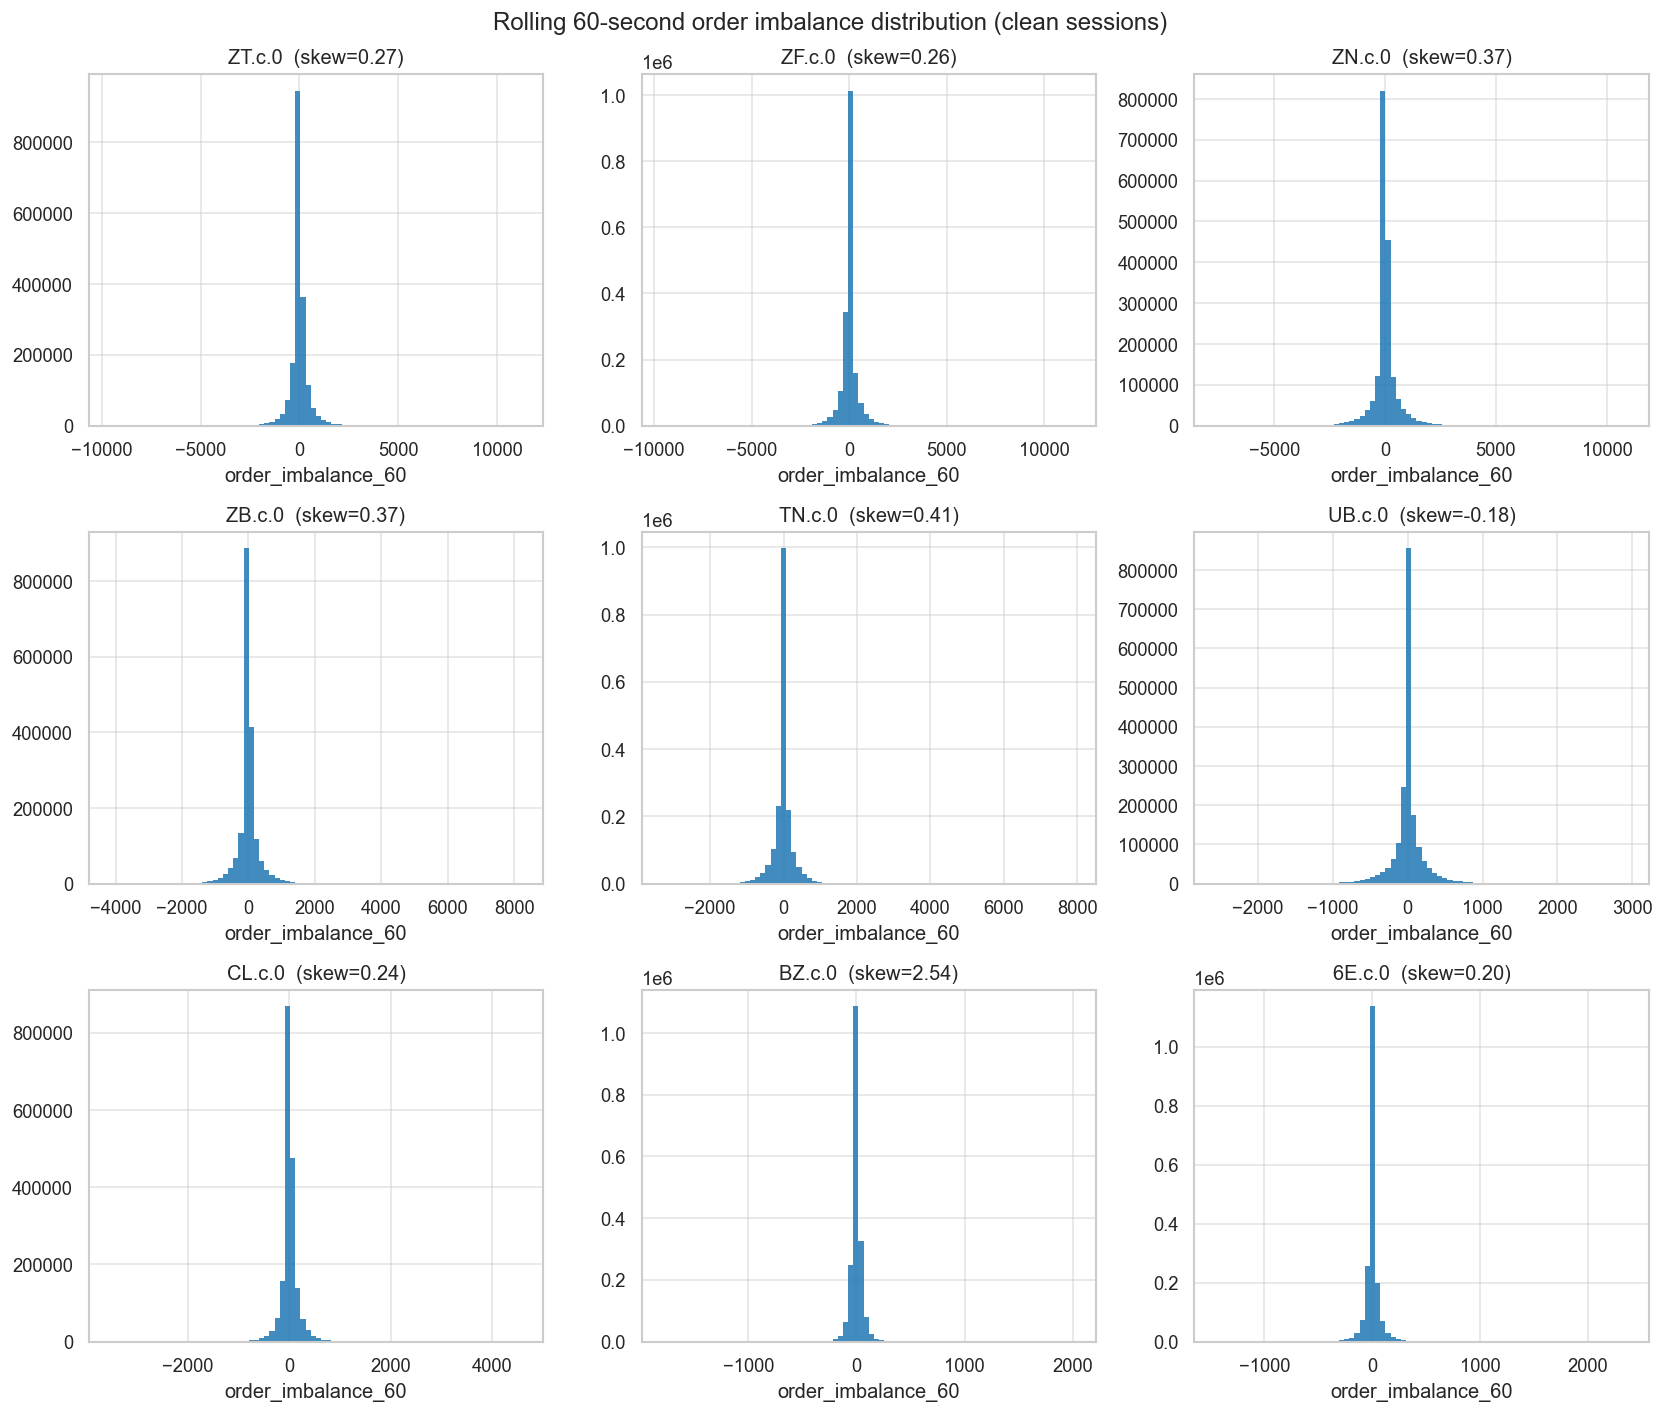

In [11]:
n_syms = len(SYMBOLS)
ncols  = 3
nrows  = (n_syms + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
for ax, sym in zip(axes.flat, SYMBOLS):
    vals = df_clean.loc[df_clean["symbol"] == sym, "order_imbalance_60"].dropna()
    ax.hist(vals, bins=80, edgecolor="none", alpha=0.85)
    ax.set_title(f"{sym}  (skew={vals.skew():.2f})")
    ax.set_xlabel("order_imbalance_60")
for ax in axes.flat[n_syms:]:
    ax.set_visible(False)
plt.suptitle("Rolling 60-second order imbalance distribution (clean sessions)")
plt.tight_layout()
plt.show()

## 8. Cross-symbol RV Correlation

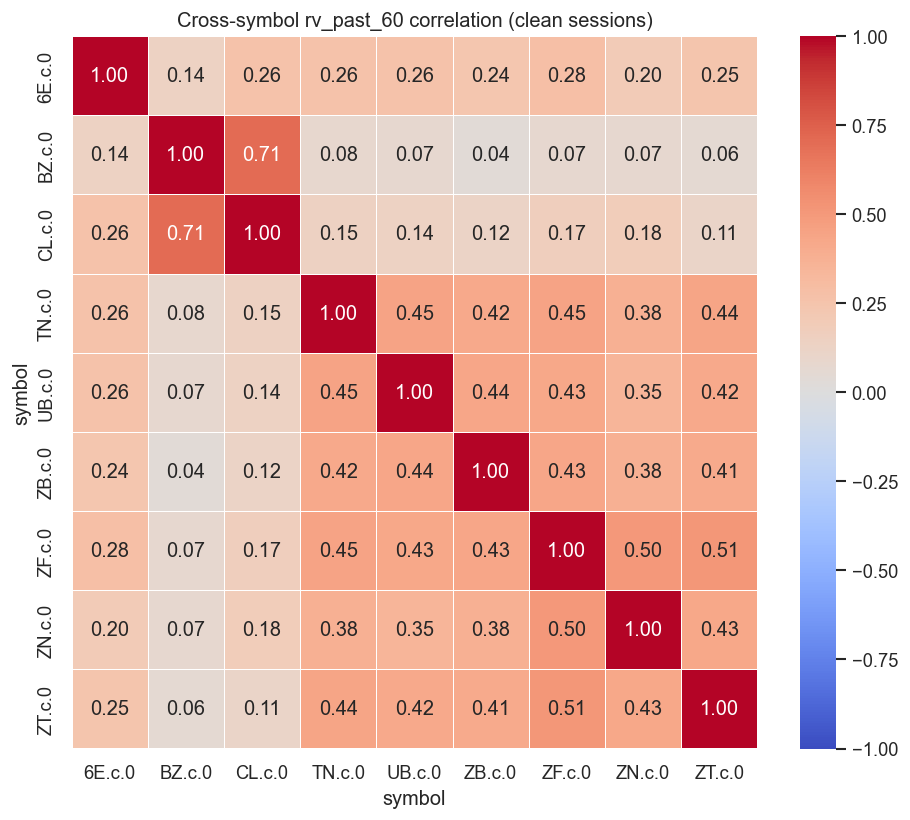

Mean cross-symbol correlation: 0.286

Modeling note:
  Treasury symbols (ZT/ZF/ZN/ZB/TN/UB) should cluster together.
  CL/BZ (crude) and 6E (FX) should be more independent.


In [12]:
rv_wide = (
    rv_clean
    .pivot_table(index="second_bucket", columns="symbol", values="rv_past_60", aggfunc="first")
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    rv_wide.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax
)
ax.set_title("Cross-symbol rv_past_60 correlation (clean sessions)")
plt.tight_layout()
plt.show()

avg_cross_corr = rv_wide.corr().values
np.fill_diagonal(avg_cross_corr, np.nan)
print(f"Mean cross-symbol correlation: {np.nanmean(avg_cross_corr):.3f}")
print("\nModeling note:")
print("  Treasury symbols (ZT/ZF/ZN/ZB/TN/UB) should cluster together.")
print("  CL/BZ (crude) and 6E (FX) should be more independent.")

## 9. Train / Val / Test Split Recommendation

Time series splits must be chronological to avoid look-ahead bias. Use `session_date` as the boundary , never split within a session.

In [13]:
clean_dates = sorted(df_clean["session_date"].unique())
n_dates = len(clean_dates)

# 70 / 15 / 15 split
train_end = clean_dates[int(n_dates * 0.70) - 1]
val_end   = clean_dates[int(n_dates * 0.85) - 1]
test_end  = clean_dates[-1]

print(f"Total clean sessions : {n_dates}")
print(f"Train : {clean_dates[0]}  →  {train_end}  ({int(n_dates*0.70)} sessions)")
print(f"Val   : {clean_dates[int(n_dates*0.70)]}  →  {val_end}  ({int(n_dates*0.15)} sessions)")
print(f"Test  : {clean_dates[int(n_dates*0.85)]}  →  {test_end}  ({n_dates - int(n_dates*0.85)} sessions)")

# example split code for modeling notebook
print("""
── Copy into modeling notebook ──────────────────────────────────────
train = df[df['session_date'] <= train_end]
val   = df[(df['session_date'] > train_end) & (df['session_date'] <= val_end)]
test  = df[df['session_date'] > val_end]
─────────────────────────────────────────────────────────────────────""")

Total clean sessions : 23
Train : 2025-11-17  →  2026-01-06  (16 sessions)
Val   : 2026-01-07  →  2026-01-09  (3 sessions)
Test  : 2026-01-12  →  2026-01-15  (4 sessions)

── Copy into modeling notebook ──────────────────────────────────────
train = df[df['session_date'] <= train_end]
val   = df[(df['session_date'] > train_end) & (df['session_date'] <= val_end)]
test  = df[df['session_date'] > val_end]
─────────────────────────────────────────────────────────────────────


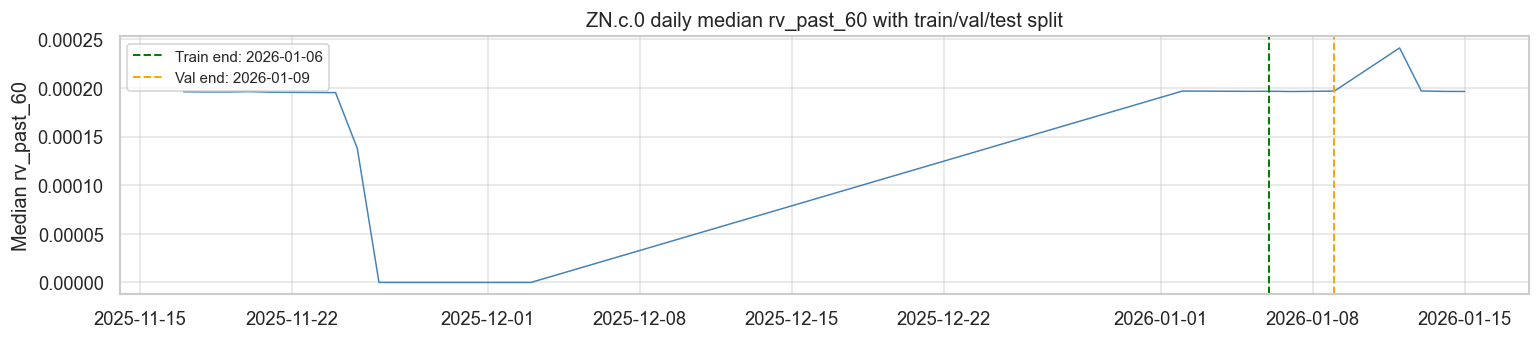

In [14]:
# visualize split on ZN.c.0 median daily RV
daily_rv = (
    df_clean[df_clean["symbol"] == "ZN.c.0"]
    .groupby("session_date")["rv_past_60"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(daily_rv["session_date"], daily_rv["rv_past_60"], linewidth=0.9, color="steelblue")
ax.axvline(train_end, color="green",  linestyle="--", linewidth=1.2, label=f"Train end: {train_end}")
ax.axvline(val_end,   color="orange", linestyle="--", linewidth=1.2, label=f"Val end: {val_end}")
ax.set_title("ZN.c.0 daily median rv_past_60 with train/val/test split")
ax.set_ylabel("Median rv_past_60")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()